In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
image_path = "sample_image.jpg"
img = np.array(Image.open(image_path).convert("L"))

In [3]:
print(f"Original image shape: {img.shape}")
print(f"Original image data type: {img.dtype}")

Original image shape: (853, 1280)
Original image data type: uint8


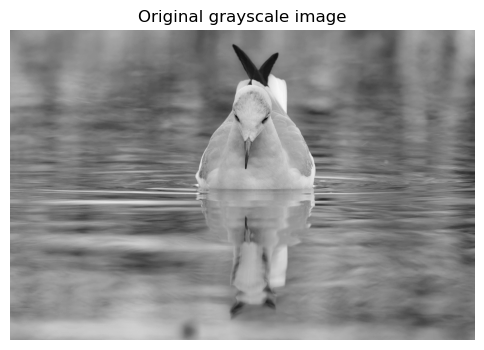

In [26]:
plt.figure(figsize=(6,5))
plt.imshow(img, cmap="gray")
plt.title("Original grayscale image")
plt.axis("off")
plt.show()

-----------------------------------------------------------------

#  __Sampling__ (changing spatial resolution)

In [15]:
def downsample(image, factor):
    return image[::factor, ::factor]

(-0.5, 1279.5, 852.5, -0.5)

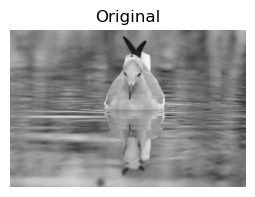

In [12]:
factors = [2,4,8]
plt.figure(figsize=(14,4))
plt.subplot(1, len(factors)+1, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

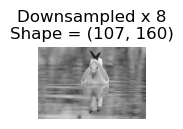

In [16]:
for i,f in enumerate(factors):
    small = downsample(img, f)
    plt.subplot(1, len(factors)+1, 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"Downsampled x {f}\nShape = {small.shape}")
    plt.axis("off")

In [20]:
small_img = downsample(img, 8)
pil_small = Image.fromarray(small_img)
upsampled = pil_small.resize((img.shape[1], img.shape[0]), Image.Resampling.NEAREST)
upsampled = np.array(upsampled)

(-0.5, 1279.5, 852.5, -0.5)

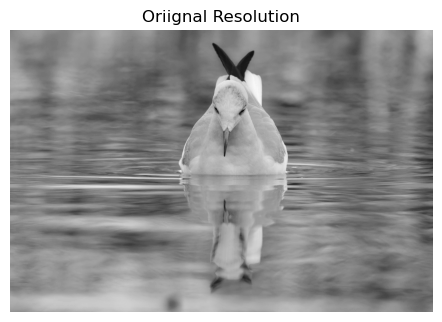

In [21]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Oriignal Resolution")
plt.axis("off")

(-0.5, 1279.5, 852.5, -0.5)

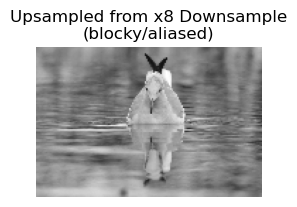

In [23]:
plt.subplot(1,2,2)
plt.imshow(upsampled, cmap="gray")
plt.title("Upsampled from x8 Downsample\n(blocky/aliased)")
plt.axis("off")

In [24]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [25]:
print("\nSampling: reducing resolution loses spatial detail permanently")
print("Upsampling only stretches existing pixels; it cannot recover lost detail")


Sampling: reducing resolution loses spatial detail permanently
Upsampling only stretches existing pixels; it cannot recover lost detail


-----------------------------------------------------------------------------

# Quantization (reducing number of gray levels)

In [37]:
def quantize(image, levels):
    step = 256 // levels
    quantized = (image // step) * step
    return quantized.astype(np.uint8)

4. Quantize image to different number of gray levels

In [38]:
level_options = [256,16,8,4,2]
plt.figure(figsize=(16,4))

<Figure size 1600x400 with 0 Axes>

<Figure size 1600x400 with 0 Axes>

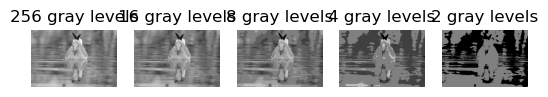

In [39]:
for i, levels in enumerate(level_options):
    q_img = quantize(img, levels)
    plt.subplot(1, len(level_options), i + 1)
    plt.imshow(q_img, cmap="gray", vmin=0, vmax=255)
    plt.title(f"{levels} gray levels")
    plt.axis("off")

In [40]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

5. Show the false contouring effect clearly with verify few levels

In [41]:
q2 = quantize(img, 2)
q4 = quantize(img, 4)

(-0.5, 1279.5, 852.5, -0.5)

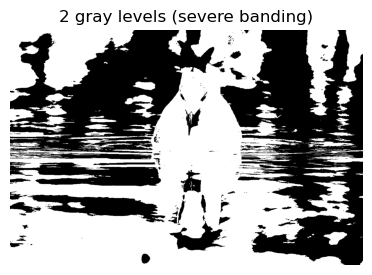

In [43]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(q2, cmap="gray")
plt.title("2 gray levels (severe banding)")
plt.axis("off")

(-0.5, 1279.5, 852.5, -0.5)

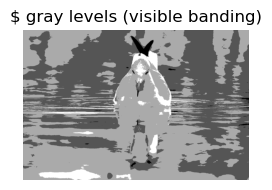

In [44]:
plt.subplot(1,2,2)
plt.imshow(q4, cmap="gray")
plt.title("$ gray levels (visible banding)")
plt.axis("off")

In [45]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [47]:
print("Quantization: reducing gray levels causes visible handling called false contouring")
print('Fewer levels = smaller file size but lower visual quality')

Quantization: reducing gray levels causes visible handling called false contouring
Fewer levels = smaller file size but lower visual quality
